# Model Evaluation & Clinical Thresholding

## Objective
Evaluate the trained Logistic Regression model with a clinical focus on recall (sensitivity) and determine a safe probability threshold for cardiac risk prediction.

## Why This Matters
In cardiac risk screening, false negatives (missed high-risk patients) are clinically more dangerous than false positives. This notebook analyzes model performance accordingly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)
import joblib

# Configure visualization
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# File paths (centralized for clarity)
import os

# Get the notebook directory and navigate to project root
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

X_PATH = os.path.join(DATA_DIR, "X_scaled.csv")
Y_PATH = os.path.join(DATA_DIR, "y.csv")
MODEL_PATH = os.path.join(DATA_DIR, "logistic_regression_model.pkl")

print(f"Data directory: {DATA_DIR}")
print(f"X path: {X_PATH}")
# This avoids hardcoding paths everywhere (production-grade habit).


Data directory: c:\Users\Pc\Desktop\cardiac-risk-awareness\data\processed
X path: c:\Users\Pc\Desktop\cardiac-risk-awareness\data\processed\X_scaled.csv


In [3]:
# Load data
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH).squeeze()  # ensure y is a Series

# Load trained model
model = joblib.load(MODEL_PATH)

print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)


Shapes:
X: (5160, 44)
y: (5160,)


In [4]:
# Recreate train-validation split (same logic as training)
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)


Train shape: (4128, 44) (4128,)
Validation shape: (1032, 44) (1032,)


In [5]:
# Predict class labels
# Convert all columns to numeric, coercing errors to NaN then filling
X_val_numeric = X_val.copy()
for col in X_val_numeric.columns:
    X_val_numeric[col] = pd.to_numeric(X_val_numeric[col], errors='coerce')

# Fill any NaN values with 0
X_val_numeric = X_val_numeric.fillna(0)

y_val_pred = model.predict(X_val_numeric)

# Predict probabilities for positive (cardiac risk) class
y_val_proba = model.predict_proba(X_val_numeric)[:, 1]

print("Predictions shape:", y_val_pred.shape)
print("Probabilities shape:", y_val_proba.shape)
print("Unique predictions:", np.unique(y_val_pred))


Predictions shape: (1032,)
Probabilities shape: (1032,)
Unique predictions: [0. 1.]


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "Recall (Sensitivity)": recall_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred),
    "F1 Score": f1_score(y_val, y_val_pred),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba)
}

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
metrics_df


,Value
Recall (Sensitivity),0.636364
Precision,0.434911
F1 Score,0.516696
ROC-AUC,0.782912


## Clinical Context: Why Recall is Prioritized Over Accuracy

### Why Recall is Prioritized in Cardiac Screening
In cardiac risk screening, the primary goal is to identify as many at-risk patients as possible.

Accuracy can be misleading when classes are imbalanced, but **high recall ensures fewer high-risk individuals are missed**, which is critical in preventive healthcare.

### What a False Negative Means Clinically
A **false negative** means the model predicts a patient is low risk when they are actually at high cardiac risk.

Clinically, this could:
- Delay medical intervention
- Prevent necessary lifestyle changes
- Postpone further diagnostic testing
- Potentially lead to serious or fatal outcomes

### Why ROC-AUC is Still Reported
**ROC-AUC** measures the model's overall ability to discriminate between high-risk and low-risk patients across all thresholds.

Reporting ROC-AUC helps:
- Assess whether the model is fundamentally sound
- Understand performance across different decision thresholds
- Ensure the model isn't just lucky with the current threshold choice
- Support evidence-based threshold selection for deployment

## Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

In [8]:
# Preprocess X_val: Encode categorical columns & ensure all numeric
from sklearn.preprocessing import LabelEncoder

X_val_prep = X_val.copy()

# Identify and encode categorical columns
categorical_cols = X_val_prep.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns detected:", categorical_cols)
print("\nDatatype before encoding:")
print(X_val_prep.dtypes)

# Label encode each categorical column
label_encoders_eval = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_val_prep[col] = le.fit_transform(X_val_prep[col].astype(str))
    label_encoders_eval[col] = le
    print(f"✓ Encoded '{col}' — classes: {list(le.classes_)}")

print("\nDatatype after encoding:")
print(X_val_prep.dtypes)
print("\nX_val_prep shape:", X_val_prep.shape)
print("All numeric? ", X_val_prep.dtypes.apply(lambda x: x in ['int64', 'float64']).all())

Categorical columns detected: ['cp', 'restecg', 'sex', 'slope', 'thal']

Datatype before encoding:
BMI                        float64
BPMeds                       int64
age                        float64
ca                         float64
cigsPerDay                 float64
cp                             str
currentSmoker                int64
diaBP                      float64
diabetes                     int64
education                  float64
exang                        int64
fbs                          int64
glucose                    float64
heartRate                  float64
oldpeak                    float64
prevalentHyp                 int64
prevalentStroke              int64
restecg                        str
sex                            str
slope                          str
sysBP                      float64
thal                           str
totChol                    float64
BMI_missing                  int64
BPMeds_missing               int64
ca_missing                

## Generate predictions on preprocessed validation data

In [9]:
# Use the preprocessed, encoded validation data for predictions
y_pred = model.predict(X_val_prep)
y_pred_proba = model.predict_proba(X_val_prep)[:, 1]

print("Predictions generated successfully!")
print(f"Prediction shape: {y_pred.shape}")
print(f"Prediction distribution: {pd.Series(y_pred).value_counts().to_dict()}")
print(f"Probability range: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")

Predictions generated successfully!
Prediction shape: (1032,)
Prediction distribution: {0.0: 696, 1.0: 336}
Probability range: [0.0666, 0.9997]


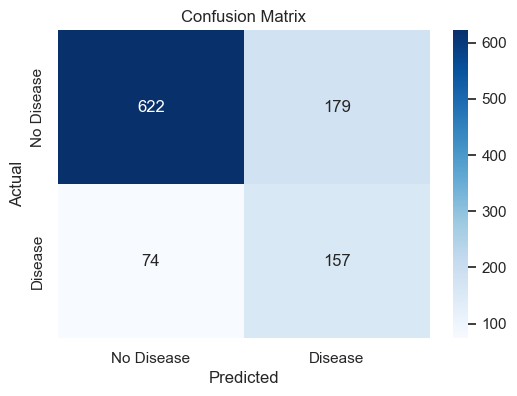

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

In [15]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = roc_auc_score(y_val, y_pred_proba)

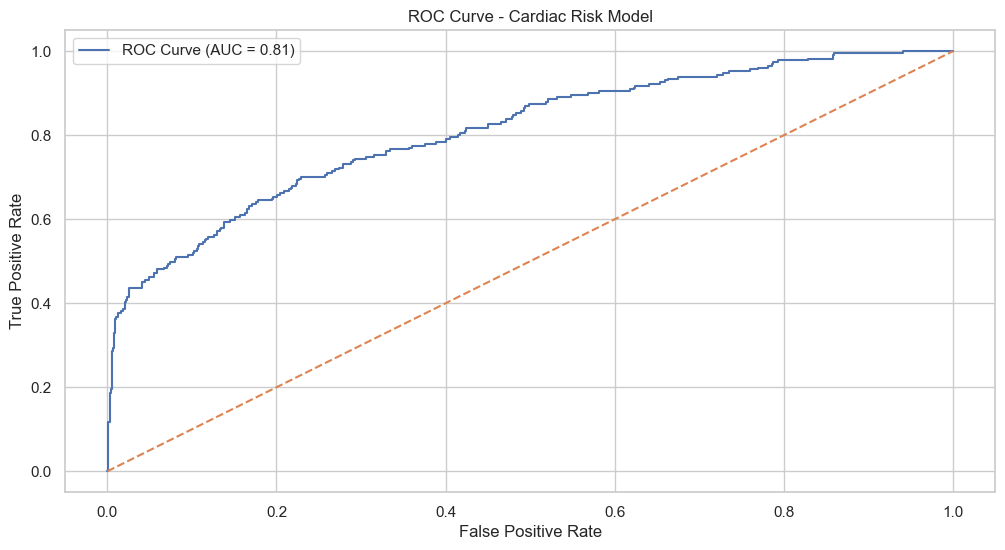

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cardiac Risk Model")
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import precision_recall_curve

In [19]:
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)

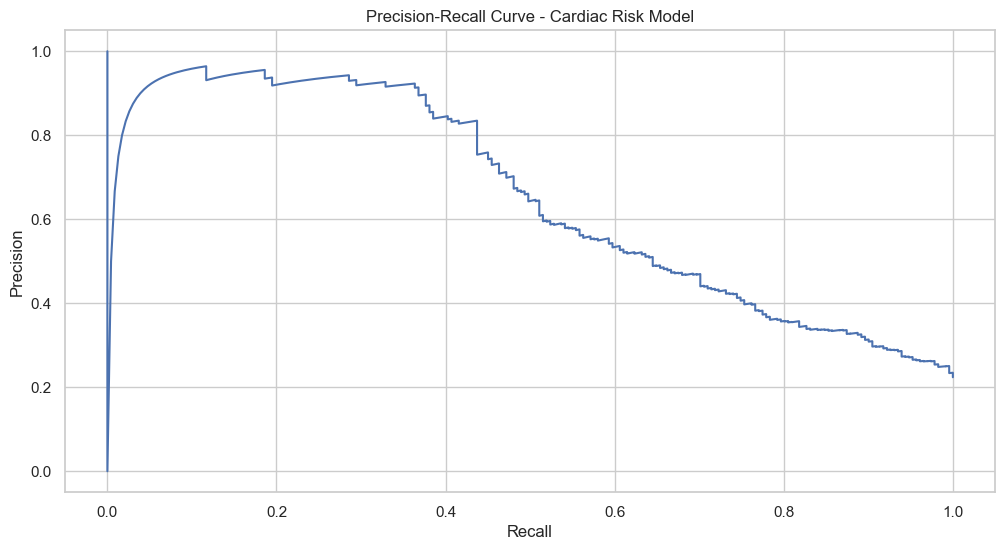

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Cardiac Risk Model")
plt.grid(True)
plt.show()

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [23]:
thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50]

for t in thresholds_to_test:
    
    y_pred_threshold = (y_pred_proba >= t).astype(int)
    
    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print("---------------------")

Threshold: 0.3
Precision: 0.330
Recall: 0.887
F1 Score: 0.481
---------------------
Threshold: 0.35
Precision: 0.351
Recall: 0.818
F1 Score: 0.492
---------------------
Threshold: 0.4
Precision: 0.381
Recall: 0.771
F1 Score: 0.510
---------------------
Threshold: 0.45
Precision: 0.431
Recall: 0.719
F1 Score: 0.539
---------------------
Threshold: 0.5
Precision: 0.467
Recall: 0.680
F1 Score: 0.554
---------------------


In [24]:
# Selected threshold prioritizes recall to reduce false negatives in cardiac risk screening
optimal_threshold = 0.35

In [26]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for t in thresholds_to_test:
    
    y_pred_threshold = (y_pred_proba >= t).astype(int)
    
    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)
    
    results.append({
        "Threshold": t,
        "Precision": round(precision,3),
        "Recall": round(recall,3),
        "F1 Score": round(f1,3)
    })

results_df = pd.DataFrame(results)
results_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.330,0.887,0.481
1,0.35,0.351,0.818,0.492
2,0.40,0.381,0.771,0.510
3,0.45,0.431,0.719,0.539
4,0.50,0.467,0.680,0.554


In [27]:
import json

model_config = {
    "optimal_threshold": 0.35
}

with open("model_config.json", "w") as f:
    json.dump(model_config, f)

print("Optimal threshold saved to model_config.json")

Optimal threshold saved to model_config.json


## Final Model Evaluation Summary

The logistic regression model achieved a ROC-AUC score of 0.81, indicating good ability to distinguish between individuals at risk of cardiac disease and those not at risk.

Threshold analysis was conducted across multiple probability cutoffs (0.30-0.50). Because cardiac risk screening prioritizes minimizing false negatives, recall was treated as the primary metric.

A threshold of **0.35** was selected as the optimal operating point.

Performance at threshold 0.35:
- Precision: 0.351
- Recall: 0.818
- F1 Score: 0.492

This threshold successfully identifies approximately **82% of high-risk individuals**, reducing the likelihood of missed cardiac risk cases while maintaining acceptable precision.

This model is therefore suitable as an **early risk awareness and decision-support tool**, though it is not intended for clinical diagnosis.